In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
x=np.array([5, 7, 9, 11, 13, 15])
y=np.array([11, 14, 20, 24, 29, 31])

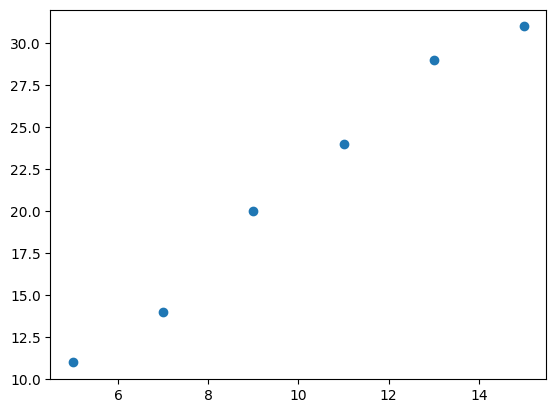

In [3]:
plt.scatter(x, y)
plt.show()

In [4]:
np.corrcoef(x, y)

array([[1.        , 0.99322298],
       [0.99322298, 1.        ]])

In [5]:
y.shape

(6,)

In [6]:
y.ndim

1

In [7]:
x.shape

(6,)

In [8]:
x.ndim

1

In [9]:
x   

array([ 5,  7,  9, 11, 13, 15])

In [10]:
x=x.reshape(-1, 1)

In [11]:
x

array([[ 5],
       [ 7],
       [ 9],
       [11],
       [13],
       [15]])

In [12]:
x.shape

(6, 1)

In [13]:
x.ndim

2

In [14]:
from sklearn.linear_model import LinearRegression

In [15]:
model = LinearRegression()

In [16]:
model.fit(x, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
model.coef_

array([2.12857143])

In [18]:
model.intercept_

np.float64(0.2142857142857153)

In [19]:
w0=model.intercept_
w1=model.coef_[0]

In [20]:
predictions=w0+np.dot(w1, x).reshape(1,-1)

In [21]:
predictions

array([[10.85714286, 15.11428571, 19.37142857, 23.62857143, 27.88571429,
        32.14285714]])

In [22]:
pred = model.predict(x)

In [23]:
pred

array([10.85714286, 15.11428571, 19.37142857, 23.62857143, 27.88571429,
       32.14285714])

In [24]:
pred == predictions

array([[ True,  True,  True,  True,  True,  True]])

In [25]:
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import r2_score as r2

In [26]:
mse(y, pred)

0.723809523809522

In [27]:
r2(y, pred)

0.9864918906909576

In [28]:
rmse = np.sqrt(mse(y, pred))

In [29]:
rmse

np.float64(0.8507699593953244)

<function matplotlib.pyplot.show(close=None, block=None)>

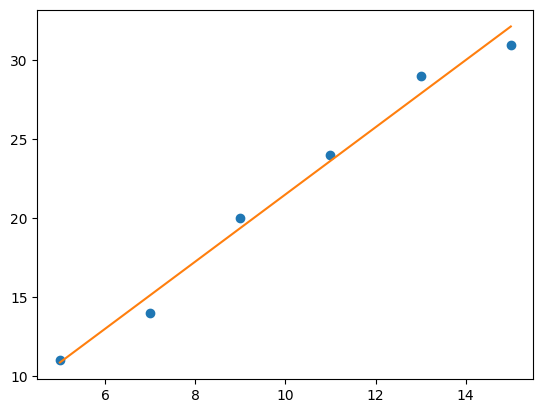

In [30]:
plt.plot(x,y,'o')
plt.plot(x,pred)
plt.show

In [31]:
model.score(x,y)

0.9864918906909576

In [32]:
dfcar = pd.read_csv('mtcars.csv')
dfcar=dfcar.rename(columns={'Unnamed: 0':'car'})
dfcar.head()

,car,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


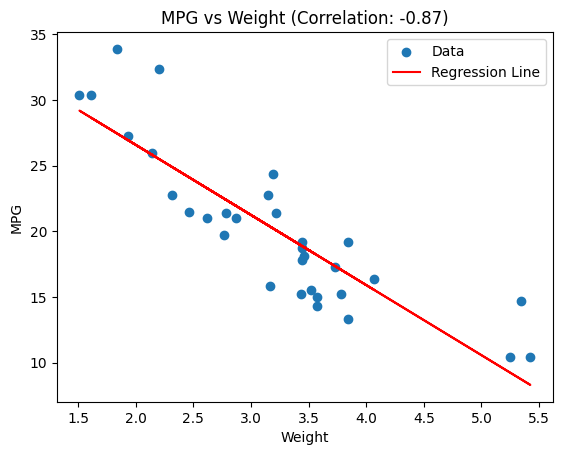

In [33]:
# Calculate correlation between 'mpg' and 'wt'
corr = np.corrcoef(dfcar['mpg'], dfcar['wt'])[0, 1]

# Fit a linear regression model to predict mpg from wt
X = dfcar[['wt']]
y = dfcar['mpg']
car_model = LinearRegression()
car_model.fit(X, y)
car_pred = car_model.predict(X)

# Plot the data and regression line
plt.scatter(dfcar['wt'], dfcar['mpg'], label='Data')
plt.plot(dfcar['wt'], car_pred, color='red', label='Regression Line')
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.title(f'MPG vs Weight (Correlation: {corr:.2f})')
plt.legend()
plt.show()

In [60]:
from sklearn import datasets
diabetes = datasets.load_diabetes()
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


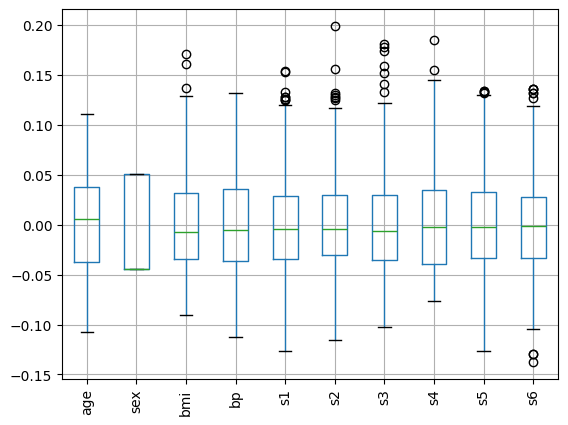

In [80]:
data = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
data.boxplot(rot=90)
data.head()

In [81]:
x = data
y = diabetes.target
lr = LinearRegression()
lr.fit(x, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [63]:
r_squared = lr.score(x, y)
r_squared

0.5177484222203498

In [64]:
adjusted_r_squared = 1 - (1 - r_squared) * (len(y) - 1) / (len(y) - x.shape[1] - 1)
adjusted_r_squared

0.5065592904853231

In [65]:
lr.coef_

array([ -10.0098663 , -239.81564367,  519.84592005,  324.3846455 ,
       -792.17563855,  476.73902101,  101.04326794,  177.06323767,
        751.27369956,   67.62669218])

In [66]:
lr.intercept_

np.float64(152.13348416289597)

Text(0, 0.5, 'Coefficient')

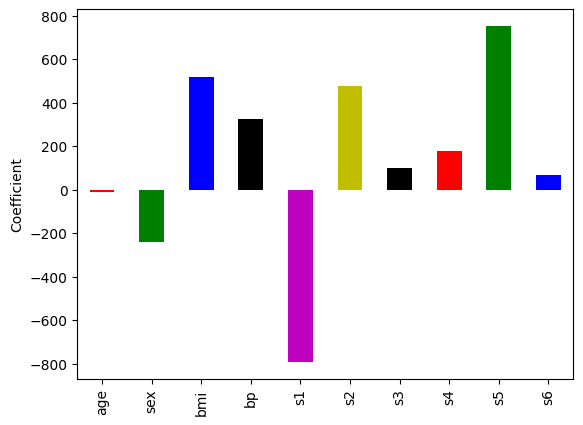

In [67]:
coef=pd.Series(lr.coef_, index=diabetes.feature_names)
coef.plot(kind='bar', color =list('rgbkmyk'))
plt.ylabel('Coefficient')

In [51]:
# Check Python health
import sys
print(f"Python version: {sys.version}")
print("✅ Python is working perfectly!")

# Check key libraries
try:
    import numpy, pandas, sklearn, matplotlib
    print("✅ All ML libraries working!")
except ImportError as e:
    print(f"❌ Library issue: {e}")
    
# Quick functionality test
import numpy as np
test_array = np.array([1, 2, 3, 4, 5])
print(f"✅ NumPy test: {test_array.mean()}")
print("🎉 Your environment is healthy!")

Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
✅ Python is working perfectly!
✅ All ML libraries working!
✅ NumPy test: 3.0
🎉 Your environment is healthy!
